In [1]:
from PyTEMGrid import tem_grid_image, holes_image, adaptive_thresh, li_threshold, yen_threshold
import matplotlib.pyplot as plt
import numpy as np


## Load and visualize data

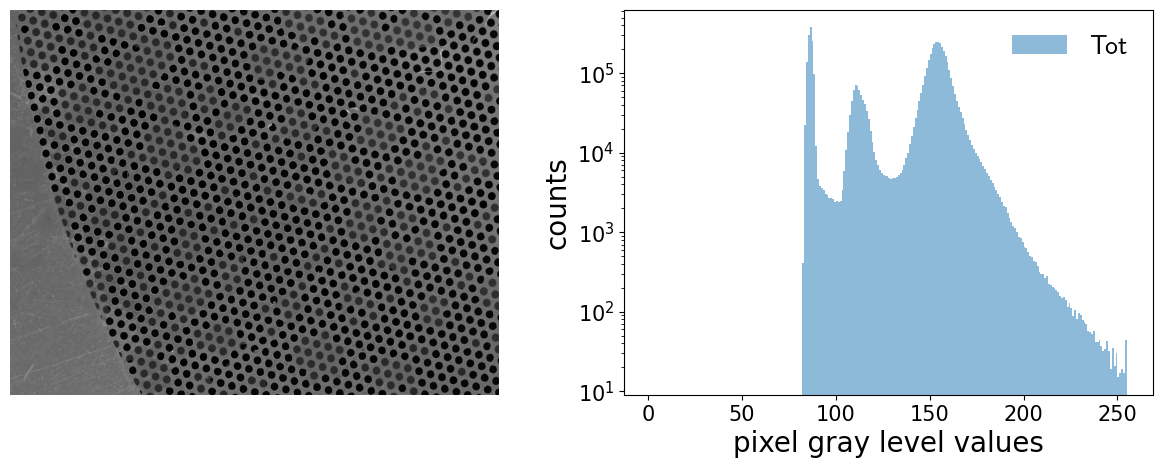

<Figure size 500x500 with 0 Axes>

In [2]:
i,j =    4, 1
image = tem_grid_image("./G1_"+str(i)+""+str(j)+".tif")
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
image.display(ax = ax1)
_ = image.hist(ax = ax2, label = "Tot")

## 1st segmentation: holes and grid

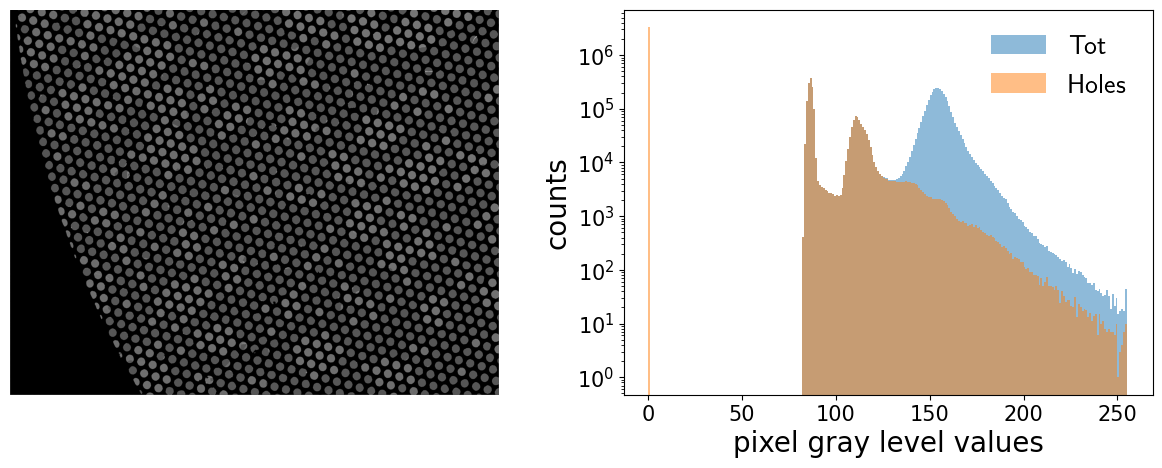

<Figure size 500x500 with 0 Axes>

In [3]:
holes, grid=image.watershed(k=0.10, radius = None, move = False) #standard segmentation
holes = holes_image(holes)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
holes.display(ax = ax1)
_ = image.hist(ax = ax2, label= "Tot")
_ = holes.hist(ax = ax2, label= "Holes")

## Compute average hole area

In [5]:
#compute the area of the holes
df, labeled = holes.analyze_particles(min_thresh=0, min_size=1200, max_size=1800, min_circ=0.92, max_circ=1)
display(df)
print("Average hole area:", df["area"].mean())
print("Standard deviation:", df["area"].std())
print("Average radius of a single hole:", np.sqrt(df["area"].mean()/np.pi))
print("Standard deviation:", np.sqrt( (df["area"].mean()+ df["area"].std())/np.pi)- np.sqrt(df["area"].mean()/np.pi ))
radius = (np.sqrt(df["area"].mean()/np.pi), np.sqrt( (df["area"].mean()+ df["area"].std())/np.pi)- np.sqrt(df["area"].mean()/np.pi ))
print("min, max:", np.min(df["area"]), np.max(df["area"]))

,label,area,perimeter,circularity,centroid_x,centroid_y,major_axis,minor_axis,bbox
0,3,1468.0,139.882251,0.942781,1077.117166,26.835150,44.560254,41.986590,"(5, 1057, 49, 1099)"
1,5,1436.0,139.882251,0.922230,1303.781337,29.639276,43.197483,42.377920,"(9, 1283, 52, 1326)"
2,12,1489.0,142.124892,0.926327,909.879785,39.641370,44.126537,42.999831,"(18, 889, 63, 932)"
3,14,1485.0,142.367532,0.920692,1136.616835,42.532660,44.330787,42.683303,"(20, 1115, 65, 1159)"
4,15,1442.0,140.124892,0.922879,1363.149098,44.717060,43.500169,42.299133,"(23, 1342, 66, 1385)"
...,...,...,...,...,...,...,...,...,...
620,1328,1456.0,140.124892,0.931839,1859.285714,2009.688187,44.683429,41.514750,"(1988, 1839, 2033, 1881)"
621,1331,1517.0,143.053824,0.931529,1015.618326,2014.460778,45.076591,42.868719,"(1993, 995, 2037, 1038)"
622,1332,1431.0,139.781746,0.920341,2312.204053,2015.604472,44.560185,40.966186,"(1993, 2292, 2038, 2334)"
623,1333,1471.0,141.296465,0.925891,1240.903467,2016.545887,43.882015,42.736220,"(1995, 1220, 2039, 1263)"


Average hole area: 1476.872
Standard deviation: 29.6731597619197
Average radius of a single hole: 21.681857813112494
Standard deviation: 0.2167316011524676
min, max: 1349.0 1552.0


Average hole area 1478.7616091426007 +- 0.9566987407108312


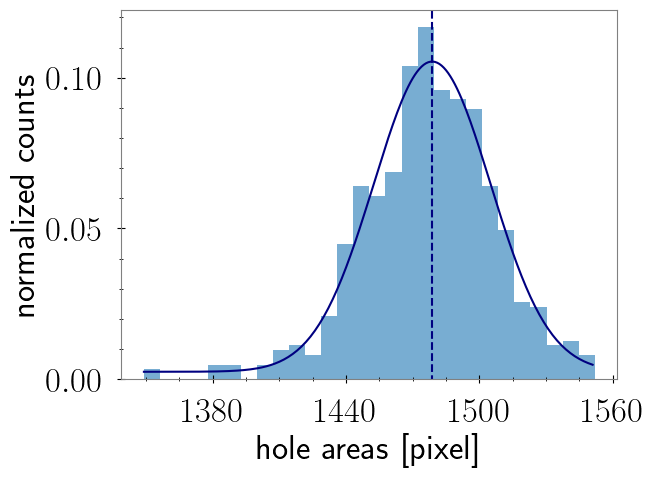

In [6]:
areas = df["area"]
_ = holes.histo_areas(areas)

## Mask correction

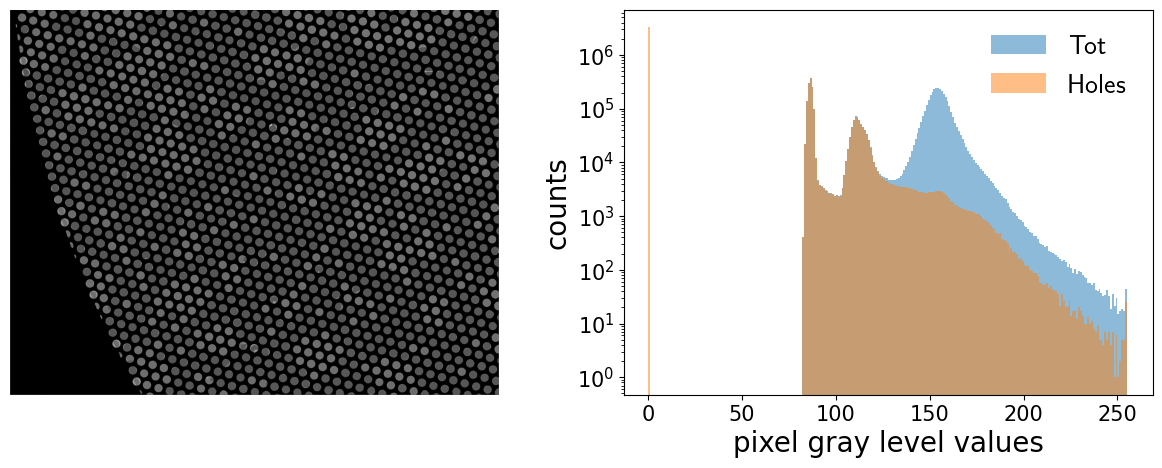

<Figure size 500x500 with 0 Axes>

In [7]:
holes, grid=image.watershed(k=0.10, radius=radius, move = False) #added holes correction
holes = holes_image(holes)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
holes.display(ax = ax1)
_ = image.hist(ax = ax2, label = "Tot")
_ = holes.hist(ax = ax2, label = "Holes")

## 2nd segmentation: covered and uncovered holes

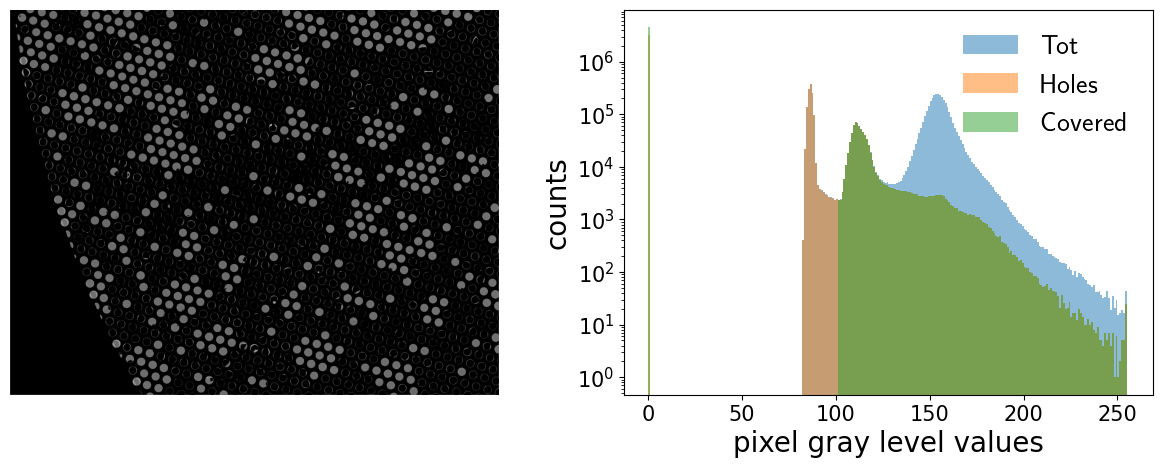

<Figure size 500x500 with 0 Axes>

In [8]:
covered, uncovered, _ = holes.saddle_point_threshold()
covered = tem_grid_image(covered)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
covered.display(ax = ax1)
_ = image.hist(ax = ax2, label= "Tot")
_ = holes.hist(ax = ax2, label= "Holes")
_ = covered.hist(ax = ax2, label= "Covered")

## compute coverage

coverage (without moving circles): 0.391941858167976
coverage (with moving circles): 0.40630313254362305


<Figure size 500x500 with 0 Axes>

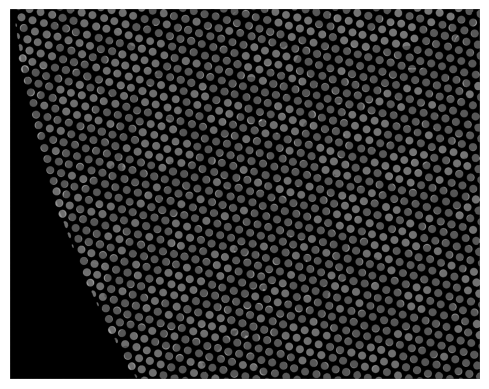

In [9]:
print("coverage (without moving circles):", holes.coverage())
#take into account uncertainty coming from the segmentation 
holes, grid = image.watershed(k = 0.10, radius = radius, move = True)
holes = holes_image(holes)
holes.display()
covered, uncovered, _ = holes.saddle_point_threshold()
print("coverage (with moving circles):", holes.coverage())

## Ancillary module

In [10]:
holes,grid, _ = adaptive_thresh(image, block_size=51, shift=10, radius = (22, 0.2), move = True)
holes = holes_image(holes)
_ = li_threshold(holes)
_ = yen_threshold(holes)


li thresh 98.20513043289823
yen thresh 120
